<a href="https://colab.research.google.com/github/AKSHAYA-1412/Python-SQL-Training/blob/main/Customer_Segmentation_K_means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

In [ ]:

# Dataset
data = [
[1,22,15000,39,4,200],
[2,25,18000,81,6,500],
[3,47,60000,40,3,150],
[4,52,65000,20,3,200],
[5,23,20000,77,5,450],
[6,45,70000,15,2,180],
[7,33,40000,50,4,300],
[8,35,42000,55,5,320],
[9,60,80000,10,1,100],
[10,28,30000,70,6,400]
]


In [ ]:
columns = ["CustomerID","Age","AnnualIncome","SpendingScore","VisitsPerMonth","AvgOrderValue"]
df = pd.DataFrame(data, columns=columns)

# Remove ID
X = df.drop("CustomerID", axis=1)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

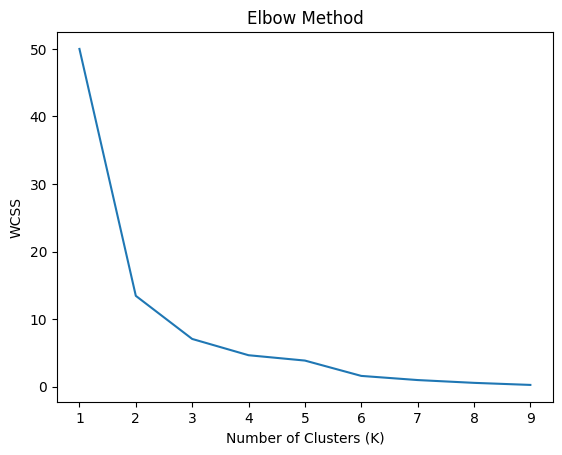

In [ ]:
# =========================
# 📊 GRAPH 1: Elbow Method
# =========================
wcss = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1,10), wcss)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

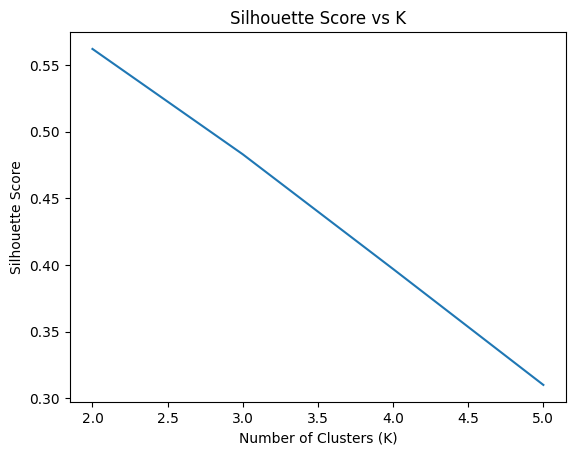

Centroids:
 [[ 1.11237302  1.10929679 -1.00863556 -1.04564501 -0.95135767]
 [-0.55618651 -0.52290084  0.09488187  0.27461384 -0.05177457]
 [-0.92697752 -0.95616154  1.24996554  1.11957951  1.32025147]]


In [ ]:

# =========================
# 📊 GRAPH 2: Silhouette Score Graph
# =========================
sil_scores = []
k_values = range(2, 6)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

plt.figure()
plt.plot(k_values, sil_scores)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.show()

In [ ]:
# =========================
# 📊 FINAL MODEL (k=3)
# =========================
kmeans = KMeans(n_clusters=3, random_state=0)
df["Cluster"] = kmeans.fit_predict(X_scaled)

print(df)


   CustomerID  Age  AnnualIncome  SpendingScore  VisitsPerMonth  \
0           1   22         15000             39               4   
1           2   25         18000             81               6   
2           3   47         60000             40               3   
3           4   52         65000             20               3   
4           5   23         20000             77               5   
5           6   45         70000             15               2   
6           7   33         40000             50               4   
7           8   35         42000             55               5   
8           9   60         80000             10               1   
9          10   28         30000             70               6   

   AvgOrderValue  Cluster  
0            200        1  
1            500        2  
2            150        0  
3            200        0  
4            450        2  
5            180        0  
6            300        1  
7            320        1  
8         

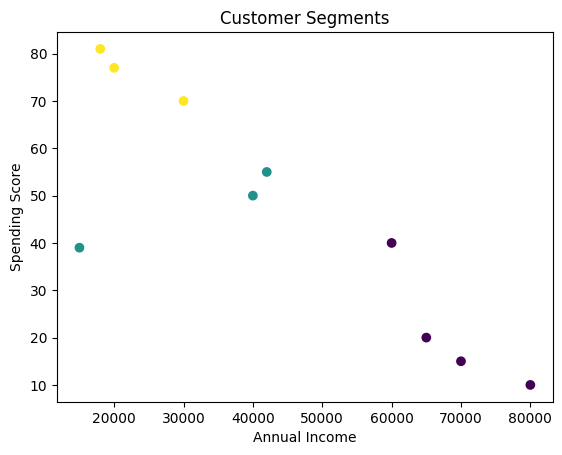

In [ ]:
# =========================
# 📊 GRAPH 3: Cluster Visualization
# =========================
plt.figure()
plt.scatter(df["AnnualIncome"], df["SpendingScore"], c=df["Cluster"])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.show()

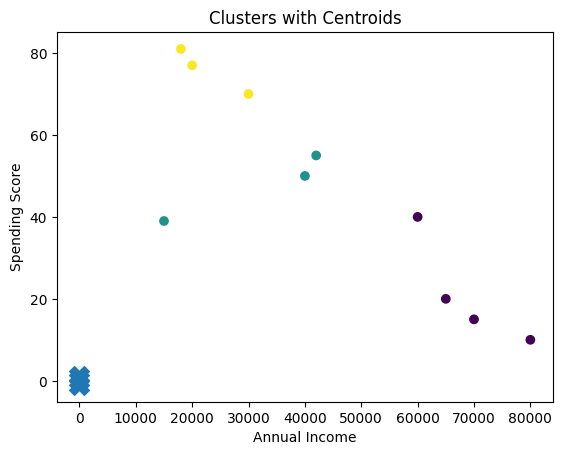

Centroids:
 [[ 1.11237302  1.10929679 -1.00863556 -1.04564501 -0.95135767]
 [-0.55618651 -0.52290084  0.09488187  0.27461384 -0.05177457]
 [-0.92697752 -0.95616154  1.24996554  1.11957951  1.32025147]]


In [ ]:
# =========================
# 📊 GRAPH 4: Centroids Visualization
# =========================
centroids = kmeans.cluster_centers_

plt.figure()
plt.scatter(df["AnnualIncome"], df["SpendingScore"], c=df["Cluster"])
plt.scatter(centroids[:,1], centroids[:,2], marker='X', s=200)  # centroids
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Clusters with Centroids")
plt.show()


# Print centroids
print("Centroids:\n", centroids)